<a href="https://colab.research.google.com/github/namithashaji/Clinic-Appointment-Analytics-and-Patient-Showed-Up-Prediction/blob/main/Clinic_Appointment_Analytics_and_Patient_Showed_Up_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinic Appointment Analytics and Patient Showed Up Prediction

# Objective

The objective of this project is to analyze Clinic appointment data and build a machine learning model capable of predicting whether a patient will attend or miss a scheduled appointment.

Missed appointments can negatively impact hospital operations, resource utilization, scheduling efficiency, and patient care management. By leveraging data analytics and predictive modeling techniques, this project aims to identify patterns associated with patient no-shows and help healthcare organizations take preventive actions.

The project includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning model comparison
- Cross validation and hyperparameter tuning
- Model evaluation using classification metrics

In [475]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Data Ingestion

In [476]:
from google.colab import files
uploaded = files.upload()
df=pd.read_csv('healthcare_noshows.csv')

Saving healthcare_noshows.csv to healthcare_noshows (6).csv


In [477]:
df.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Temp_Column,Unnamed: 0,Previous_No_Shows
0,564184,8133951,F,2025-05-24 23:00:00,2025-05-28 23:00:00,49.0,Centro,0,0,0,0,2,0.0,Yes,TMP,3455,1
1,202478,1740079,M,2025-12-02 23:00:00,2025-12-06 23:00:00,46.0,Jardim Camburi,0,0,1,0,0,0.0,No,TMP,8063,3
2,991798,5037584,M,2026-04-29 23:00:00,2026-05-03 23:00:00,79.0,Santo Antonio,0,0,0,0,0,NaN,Yes,NaN,11615,3
3,903446,6535128,F,2025-04-22 13:00:00,2025-04-26 13:00:00,8.0,Bela Vista,0,0,0,0,0,1.0,No,TMP,2677,0
4,782886,6979212,M,2025-10-11 02:00:00,2025-10-15 02:00:00,58.0,Itarare,0,0,0,0,0,1.0,No,TMP,6794,1


## Data Exploration

In [478]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(12300, 17)

Column Names:
Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show',
       'Temp_Column', 'Unnamed: 0', 'Previous_No_Shows'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12300 entries, 0 to 12299
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientId          12300 non-null  int64  
 1   AppointmentID      12300 non-null  int64  
 2   Gender             12300 non-null  object 
 3   ScheduledDay       12300 non-null  object 
 4   AppointmentDay     12300 non-null  object 
 5   Age                11564 non-null  float64
 6   Neighbourhood      11588 non-null  object 
 7   Scholarship        12300 non-null  int64  
 8   Hipertension       12300 non-null  int64  
 9   

In [479]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Unnamed: 0,Previous_No_Shows
count,12300.000000,1.230000e+04,11564.000000,12300.000000,12300.000000,12300.000000,12300.000000,12300.000000,11568.000000,12300.00000,12300.000000
mean,553183.848537,5.496106e+06,48.205379,0.198537,0.301626,0.146504,0.081789,0.201220,0.652317,6149.50000,0.994553
std,259998.393113,2.581627e+06,29.760439,0.398914,0.458982,0.353625,0.274054,0.540045,0.476255,3550.84849,0.999985
min,100126.000000,1.000037e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,328257.250000,3.268170e+06,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3074.75000,0.000000
50%,553297.000000,5.529443e+06,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6149.50000,1.000000
75%,778192.250000,7.700892e+06,72.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,9224.25000,2.000000
max,999885.000000,9.999890e+06,200.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,12299.00000,6.000000


## Data Cleaning

In [480]:
# Analyzing Missing value count
missing_values = df.isna().sum()
missing_values[missing_values > 0]



,0
Age,736
Neighbourhood,712
SMS_received,732
Temp_Column,3136


In [481]:
missing_percent= (df.isna().sum()/len(df))*100
missing_percent[missing_percent>0]

,0
Age,5.983740
Neighbourhood,5.788618
SMS_received,5.951220
Temp_Column,25.495935


In [482]:
# Removing unnecessary columns
df.drop(columns=['PatientId','AppointmentID','Temp_Column','Unnamed: 0'],inplace=True)

## Input Standardization

In [483]:
#Listing unique values
df['Neighbourhood'].unique()

array(['Centro', 'Jardim Camburi', 'Santo Antonio', 'Bela Vista',
       'Itarare', 'Andorinhas', ' Jardim Camburi ', 'Maria Ortiz',
       ' Santo Antonio ', ' Maria Ortiz ', ' Bela Vista ', nan,
       ' Itarare ', ' nan ', ' Centro ', ' Andorinhas '], dtype=object)

In [484]:
#Removing whitespace
df['Neighbourhood']=df['Neighbourhood'].str.strip()

In [485]:
df['Neighbourhood'].unique()

array(['Centro', 'Jardim Camburi', 'Santo Antonio', 'Bela Vista',
       'Itarare', 'Andorinhas', 'Maria Ortiz', nan, 'nan'], dtype=object)

In [486]:
#Replacing value 'nan' with null
df['Neighbourhood'] = df['Neighbourhood'].replace('nan',np.nan)

In [487]:
df['Gender'].unique()

array(['F', 'M', 'm', 'female', ' FEMALE ', 'male', ' MALE ', 'Female',
       'f', 'Male'], dtype=object)

In [488]:
# Converting Gender values to single format
df['Gender'] = (df['Gender'].astype(str).str.strip().str.lower())

df['Gender'] = df['Gender'].replace({'m': 'male', 'male': 'male', 'f': 'female', 'female': 'female'})

In [489]:
# Converting datetime format to Standard format
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'],errors='coerce')
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce')

## Handling Missing Values

In [490]:
# Simple Imputer used fill null values
mode_imputer = SimpleImputer(strategy='most_frequent') # for categorical value
df['Neighbourhood'] = mode_imputer.fit_transform(df[['Neighbourhood']]).ravel()
df['SMS_received'] = mode_imputer.fit_transform(df[['SMS_received']]).ravel()
mean_imputer=SimpleImputer(strategy='mean') # for numerical value
df['Age']= mean_imputer.fit_transform(df[['Age']])

In [491]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


## Handling Outliers

<Axes: ylabel='Age'>

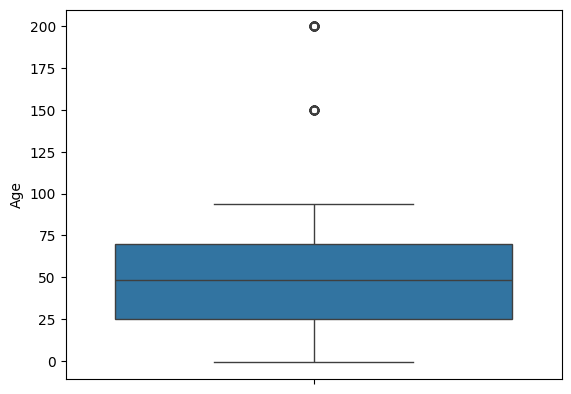

In [492]:
sns.boxplot(df['Age'])

In [493]:
df['Age'][(df['Age']<0) | (df['Age']>100)].count()

np.int64(123)

In [494]:
# Removing invalid age
df.drop(df[(df['Age']<0) | (df['Age']>100)].index,inplace=True)
df.reset_index(drop=True, inplace=True)

## Feature Creation

In [495]:
# Creating feature 'Waiting_days'
df['Waiting_Days']=(df['AppointmentDay']-df['ScheduledDay']).dt.days

In [496]:
# Extracting month and Week from Appointment Date
df['Appointment_Month'] = (df['AppointmentDay'].dt.month)
df['Appointment_DayOfWeek'] = (df['AppointmentDay'].dt.dayofweek)

In [497]:
# Removing unwanted columns
df.drop(columns=['ScheduledDay','AppointmentDay'],inplace=True)

## Data Type conversion

In [498]:
df.dtypes

,0
Gender,object
Age,float64
Neighbourhood,object
Scholarship,int64
Hipertension,int64
Diabetes,int64
Alcoholism,int64
Handcap,int64
SMS_received,float64
No-show,object


In [499]:
# Converting dtype to int
df['Age']=df['Age'].astype(int)
df['SMS_received']=df['SMS_received'].astype(int)

## Handling Duplicates

In [500]:
# Checking for duplicates
df.duplicated().sum()

np.int64(86)

In [501]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [502]:
df.head()

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Previous_No_Shows,Waiting_Days,Appointment_Month,Appointment_DayOfWeek
0,female,49,Centro,0,0,0,0,2,0,Yes,1,4,5,2
1,male,46,Jardim Camburi,0,0,1,0,0,0,No,3,4,12,5
2,male,79,Santo Antonio,0,0,0,0,0,1,Yes,3,4,5,6
3,female,8,Bela Vista,0,0,0,0,0,1,No,0,4,4,5
4,male,58,Itarare,0,0,0,0,0,1,No,1,4,10,2


In [503]:
df_bkp=df.copy()

## Feature Transformation

In [504]:
# Label Encoding for Binary categorical values
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['No-show']=le.fit_transform(df['No-show'])

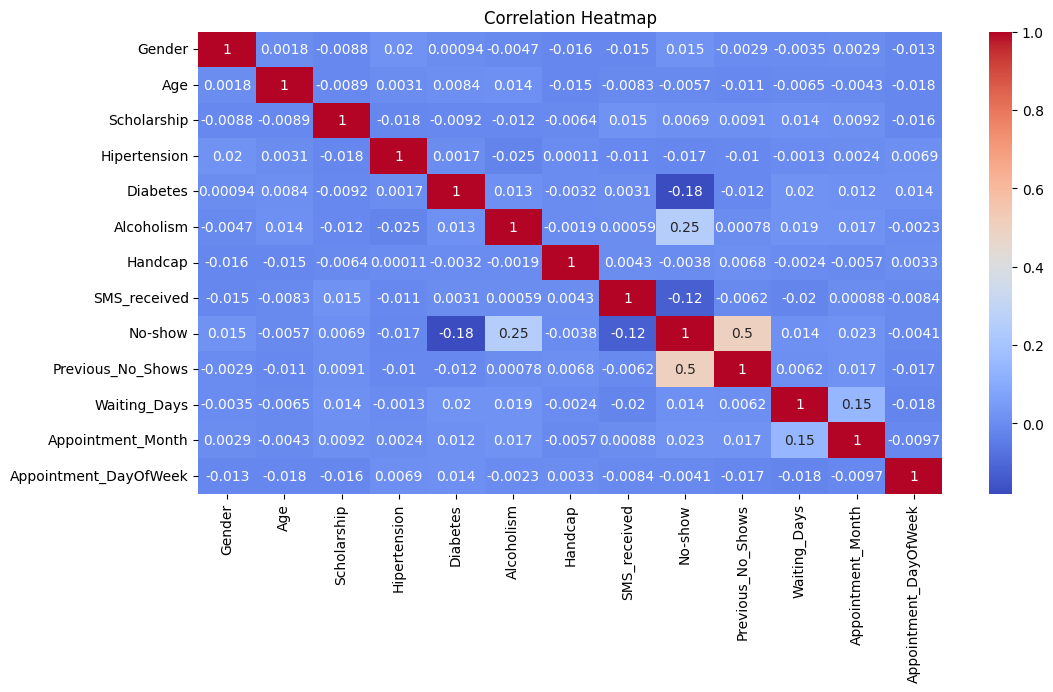

In [505]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insight
* The correlation heatmap indicates that most features exhibit weak to moderate relationships with appointment no-shows, suggesting that patient attendance behavior is influenced by multiple combined factors rather than a single dominant variable.

* Previous missed appointments showed the strongest positive correlation with future no-shows, indicating that historical attendance behavior is an important predictive factor. Alcoholism also demonstrated a moderate positive relationship with appointment no-shows.

* On the other hand, SMS reminders and diabetes showed negative correlations with no-show behavior, suggesting that reminder systems and regular medical follow-ups may improve appointment attendance.

In [506]:
# One Hot Encoding for nominal categorical values
one_hot_encoder=OneHotEncoder(sparse_output=False)
encoded_data=one_hot_encoder.fit_transform(df[['Neighbourhood']])
encoded_df=pd.DataFrame(encoded_data,columns=one_hot_encoder.get_feature_names_out(['Neighbourhood']))


df=pd.concat([df.drop(['Neighbourhood'],axis=1),encoded_df],axis=1)
df.head()

,Gender,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Previous_No_Shows,Waiting_Days,Appointment_Month,Appointment_DayOfWeek,Neighbourhood_Andorinhas,Neighbourhood_Bela Vista,Neighbourhood_Centro,Neighbourhood_Itarare,Neighbourhood_Jardim Camburi,Neighbourhood_Maria Ortiz,Neighbourhood_Santo Antonio
0,0,49,0,0,0,0,2,0,1,1,4,5,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,46,0,0,1,0,0,0,0,3,4,12,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,79,0,0,0,0,0,1,1,3,4,5,6,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,8,0,0,0,0,0,1,0,0,4,4,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,58,0,0,0,0,0,1,0,1,4,10,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [507]:
# Seperating input variables and target
X = df.drop('No-show',axis=1)
y = df['No-show']

print(X.shape)
print(y.shape)


(12091, 19)
(12091,)


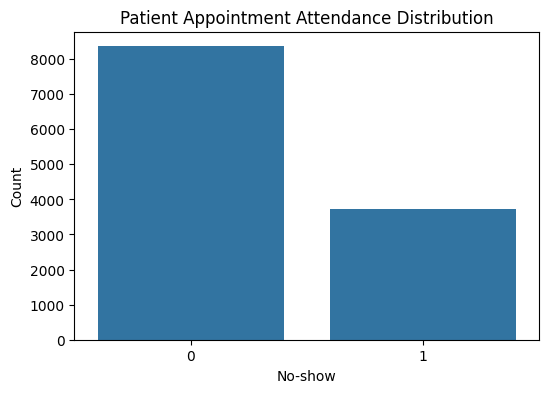

In [508]:
plt.figure(figsize=(6,4))

sns.countplot(x=y,data=df)
plt.title('Patient Appointment Attendance Distribution')
plt.xlabel('No-show')
plt.ylabel('Count')
plt.show()

### Insight
Most patients attended their appointments, while a smaller percentage missed appointments. This indicates that the dataset is imbalanced, making metrics such as F1-score important for model evaluation.

In [509]:
# Splitting the dataset for Training and Testing
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)
x_train.shape,x_test.shape

((9672, 19), (2419, 19))

In [510]:
# Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Model Building and Training

In [511]:
# Model Instantiation
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(x_train,y_train) # Model training

    y_pred = model.predict(x_test) # Model Prediction

    # Model Evaluation
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test,y_pred)

    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(x_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    results.append({
      'Model': name,
      'Accuracy': accuracy,
      'Precision': precision,
      'Recall': recall,
      'F1 Score': f1,
      'ROC AUC': roc_auc})




In [512]:
# Printing Evaluation Metrics
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.855312   0.816294  0.684987  0.744898  0.862985
1        Decision Tree  0.779661   0.645691  0.632708  0.639133  0.738948
2        Random Forest  0.860273   0.812883  0.710456  0.758226  0.881843
3                  SVM  0.866474   0.827907  0.715818  0.767793  0.858249
4    Gradient Boosting  0.868541   0.832298  0.718499  0.771223  0.893980


In [513]:
# Selecting best model based on highest F1 Score
best_model_result=results_df.sort_values(by='F1 Score', ascending=False).iloc[0]
print(best_model_result)

Model        Gradient Boosting
Accuracy              0.868541
Precision             0.832298
Recall                0.718499
F1 Score              0.771223
ROC AUC                0.89398
Name: 4, dtype: object


Among all evaluated machine learning algorithms, Gradient Boosting achieved the best overall performance based on F1-score and ROC-AUC score.

The model demonstrated balanced Precision and Recall while effectively handling the imbalanced healthcare dataset.

In [514]:
best_model_name = best_model_result['Model']
best_model = models[best_model_name]

y_pred = best_model.predict(x_test)

In [515]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1673
           1       0.83      0.72      0.77       746

    accuracy                           0.87      2419
   macro avg       0.86      0.83      0.84      2419
weighted avg       0.87      0.87      0.87      2419



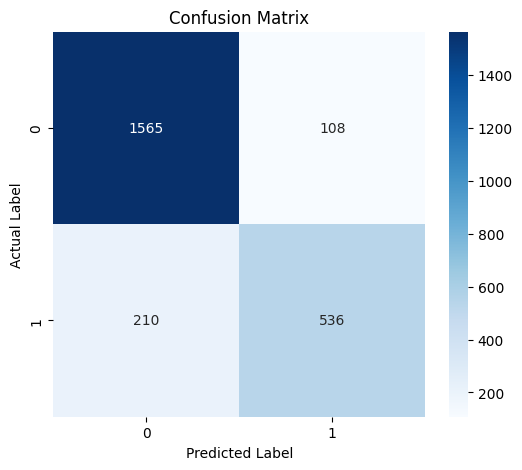

In [516]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

### Insight
* The confusion matrix indicates that the model achieved strong overall classification performance with a high number of correct predictions for both attended and missed appointments.

* The model correctly identified 1565 attended appointments and 536 missed appointments, while maintaining relatively lower false predictions. Although some no-show cases were still misclassified as attended appointments, the model demonstrated good capability in identifying patient no-show behavior.

ROC-AUC Score: 0.8939804880862907


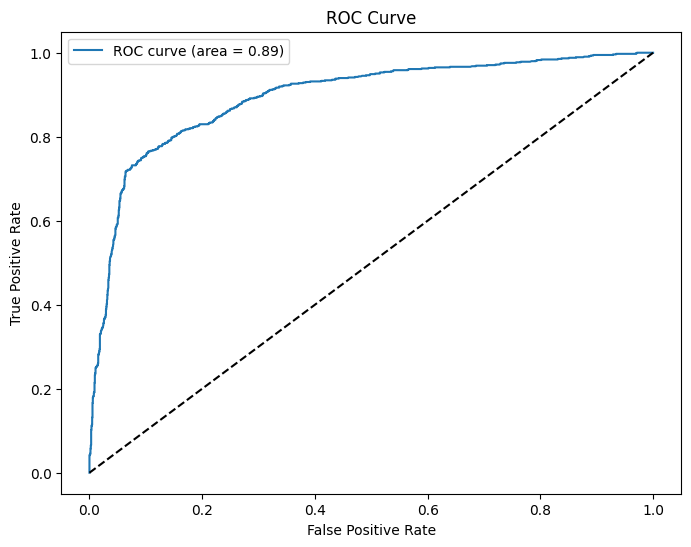

In [517]:
y_prob = best_model.predict_proba(x_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Insight
* The ROC curve demonstrates strong classification performance, with an ROC-AUC score of approximately 0.89. This indicates that the model has a high capability to distinguish between patients who will attend appointments and those who are likely to miss them.

* The ROC curve remains significantly above the random classification baseline, showing that the model achieves a good balance between True Positive Rate and False Positive Rate across different threshold values.

## Hyperparameter Tuning

In [518]:
# Cross-Validation

score= cross_val_score(best_model, x_train, y_train,cv=5, scoring='f1')
cv_results = score.mean()
print(f"Gradient Boosting: {score.mean(): 4f}")

Gradient Boosting:  0.782545


Cross validation results were close to test set performance, indicating stable generalization and low overfitting.

In [519]:
param_grid={"n_estimators": [50, 100], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}

In [520]:
#Grid Search to analyze best parameter and best score
grid_search=GridSearchCV(best_model,param_grid=param_grid,cv=5,scoring='f1')
grid_search.fit(x_train,y_train)
best_gb_model = grid_search.best_estimator_
print(f"Best Parameters for {best_model_name}: {grid_search.best_params_}")
print(f"Best Score for {best_model_name}: {grid_search.best_score_:.4f}")

Best Parameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Score for Gradient Boosting: 0.7850


In [521]:
# Model Prediction
y_pred_tuned = best_gb_model.predict(x_test)

# Model evaluation after fine-tuning
accuracy = accuracy_score(y_test,y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned)
recall = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test,y_pred_tuned)

if hasattr(model, 'predict_proba'):
  y_pred_proba = model.predict_proba(x_test)[:, 1]
  roc_auc = roc_auc_score(y_test, y_pred_proba)
else:
  roc_auc = None
tuned_results=[]
tuned_results.append({
      'Model': best_model_name,
      'Accuracy': accuracy,
      'Precision': precision,
      'Recall': recall,
      'F1 Score': f1,
      'ROC AUC': roc_auc})

In [522]:
tuned_results_df = pd.DataFrame(tuned_results)
print(tuned_results_df)


               Model  Accuracy  Precision    Recall  F1 Score  ROC AUC
0  Gradient Boosting  0.868541   0.832298  0.718499  0.771223  0.89398



Hyperparameter tuning using GridSearchCV further validated that the selected model configuration was near-optimal for the dataset.

## Final Conclusion

This project successfully demonstrated an end-to-end machine learning workflow for predicting patient appointment attendance using clinic analytics data.

Gradient Boosting emerged as the best performing model based on evaluation metrics such as F1-score and ROC-AUC score.

The analysis identified several important behavioral and operational patterns associated with appointment no-shows, including previous attendance history and reminder notifications.

This predictive system can help healthcare organizations:
- Reduce appointment no-shows
- Improve scheduling efficiency
- Optimize healthcare resource allocation
- Enhance patient engagement strategies